# 06 - Forecasting Models

**Purpose:** compare baselines and scikit-learn models for two tasks:

- next-month review-count regression;
- attention-pulse classification.

The main comparison is whether stronger model families, probability diagnostics, and reduced feature sets improve on the earlier Random Forest ablations while keeping the workflow interpretable.

In [1]:
# Load modeling data, define output paths, and import sklearn model families.
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"
METRICS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_metrics.csv"
PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_predictions.csv"
PULSE_METRICS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_metrics.csv"
PULSE_PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_predictions.csv"
PULSE_TOPK_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_topk_metrics.csv"
PULSE_CALIBRATION_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_calibration.csv"

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
modeling = pd.read_csv(FORECASTING_DATASET_PATH)
business_lookup = pd.read_csv(COHORT_BUSINESSES_PATH)[["business_id", "name", "categories"]]
print(modeling.shape)
modeling.head()

(68249, 111)


,business_id,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,...,feature_month_str,target_month_str,calendar_month,month_sin,month_cos,feature_month_number,pulse_baseline_reviews,pulse_relative_lift,attention_pulse,first_active_feature_month_str
0,-1XSzguS6XLN-V6MVZMg2A,6,29.0,6,2.000000,1.000000,0.0,6,29.0,4.833333,...,2015-12,2016-01,12,-2.449294e-16,1.000000e+00,12,1.000000,6.000000,1,2015-12
1,-1XSzguS6XLN-V6MVZMg2A,6,30.0,6,4.000000,2.000000,0.0,12,59.0,4.916667,...,2016-01,2016-02,1,5.000000e-01,8.660254e-01,13,2.000000,8.500000,1,2015-12
2,-1XSzguS6XLN-V6MVZMg2A,17,84.0,17,9.666667,4.833333,0.0,29,143.0,4.931034,...,2016-02,2016-03,2,8.660254e-01,5.000000e-01,14,4.833333,2.896552,1,2015-12
3,-1XSzguS6XLN-V6MVZMg2A,14,67.0,14,12.333333,7.166667,0.0,43,210.0,4.883721,...,2016-03,2016-04,3,1.000000e+00,6.123234e-17,15,7.166667,2.790698,1,2015-12
4,-1XSzguS6XLN-V6MVZMg2A,20,97.0,20,17.000000,10.500000,0.0,63,307.0,4.873016,...,2016-04,2016-05,4,8.660254e-01,-5.000000e-01,16,10.500000,1.142857,0,2015-12


## Chronological Splits

Each evaluation split now has three periods:

- **train:** fit the model;
- **validation:** tune the attention-pulse decision threshold;
- **test:** report final performance.

This keeps threshold tuning separate from the final test period. The primary split still evaluates COVID-era robustness, while the secondary split checks pre-COVID predictability.

## Feature Groups

Compare interpretable modality groups: historical review behavior, business metadata, SNA exposure, NLP text signals, and all modalities combined.

The NLP group automatically includes the capped TF-IDF topic indicators generated in notebook `05`, so the ablation tests whether recent review language adds signal beyond counts and metadata.

## Attention-Pulse Models

Pulse models are evaluated in three ways:

- thresholded classification metrics using a validation-tuned cutoff;
- top-k retrieval metrics, which ask whether the model can surface the most likely 5%, 10%, or 20% of future attention pulses;
- probability diagnostics using Brier score and calibration bins.

Because pulses are rare, F1, PR-AUC, precision@k, recall@k, and calibration are more informative than accuracy alone.

In [2]:
# Define metrics, split helpers, model builders, and feature groups.
def wape(y_true, y_pred):
    denominator = np.sum(np.abs(y_true))
    return np.nan if denominator == 0 else np.sum(np.abs(y_true - y_pred)) / denominator


def safe_auc(metric_fn, y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return metric_fn(y_true, score)


def period_label(split, prefix):
    return f"{split[f'{prefix}_start']} to {split[f'{prefix}_end']}"


def split_modeling_data(split):
    train_mask = (modeling["target_month_str"] >= split["train_start"]) & (modeling["target_month_str"] <= split["train_end"])
    validation_mask = (modeling["target_month_str"] >= split["validation_start"]) & (modeling["target_month_str"] <= split["validation_end"])
    test_mask = (modeling["target_month_str"] >= split["test_start"]) & (modeling["target_month_str"] <= split["test_end"])
    return modeling[train_mask].copy(), modeling[validation_mask].copy(), modeling[test_mask].copy()


def evaluate_regression(split_name, model_name, y_true, y_pred, split):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {
        "split": split_name,
        "task": "review_count_regression",
        "model": model_name,
        "train_period": period_label(split, "train"),
        "validation_period": period_label(split, "validation"),
        "test_period": period_label(split, "test"),
        "rows": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "WAPE": wape(y_true, y_pred),
    }


def classification_metric_values(y_true, y_pred, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0, 1)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": safe_auc(roc_auc_score, y_true, y_score),
        "PR_AUC": safe_auc(average_precision_score, y_true, y_score),
        "Brier": brier_score_loss(y_true, y_score),
    }


def evaluate_classification(
    split_name,
    model_name,
    y_true,
    y_pred,
    y_score,
    split,
    decision_threshold,
    threshold_source,
    validation_metrics=None,
):
    y_true = np.asarray(y_true, dtype=int)
    metrics = classification_metric_values(y_true, y_pred, y_score)
    validation_metrics = validation_metrics or {}
    return {
        "split": split_name,
        "task": "attention_pulse_classification",
        "model": model_name,
        "train_period": period_label(split, "train"),
        "validation_period": period_label(split, "validation"),
        "test_period": period_label(split, "test"),
        "rows": len(y_true),
        "positive_rate": y_true.mean(),
        "decision_threshold": decision_threshold,
        "threshold_source": threshold_source,
        "validation_precision": validation_metrics.get("precision", np.nan),
        "validation_recall": validation_metrics.get("recall", np.nan),
        "validation_F1": validation_metrics.get("F1", np.nan),
        "validation_Brier": validation_metrics.get("Brier", np.nan),
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "F1": metrics["F1"],
        "ROC_AUC": metrics["ROC_AUC"],
        "PR_AUC": metrics["PR_AUC"],
        "Brier": metrics["Brier"],
    }


# Tune classification thresholds on validation data instead of using a default 0.5 cutoff.
def tune_threshold(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0, 1)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        threshold = 0.5
        y_pred = (y_score >= threshold).astype(int)
        return threshold, classification_metric_values(y_true, y_pred, y_score)

    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_score >= threshold).astype(int)
        values = classification_metric_values(y_true, y_pred, y_score)
        rows.append({
            "threshold": threshold,
            "precision": values["precision"],
            "recall": values["recall"],
            "F1": values["F1"],
        })
    threshold_grid = pd.DataFrame(rows)
    best = threshold_grid.sort_values(["F1", "precision", "recall"], ascending=[False, False, False]).iloc[0]
    threshold = float(best["threshold"])
    y_pred = (y_score >= threshold).astype(int)
    return threshold, classification_metric_values(y_true, y_pred, y_score)


def evaluate_top_k(split_name, model_name, y_true, y_score, split, k_values):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    order = np.argsort(-y_score)
    total_positives = int(y_true.sum())
    base_rate = y_true.mean() if len(y_true) else np.nan
    rows = []
    for k_fraction in k_values:
        selected_count = max(1, int(np.ceil(len(y_true) * k_fraction)))
        selected = order[:selected_count]
        selected_positives = int(y_true[selected].sum())
        precision_at_k = selected_positives / selected_count
        recall_at_k = np.nan if total_positives == 0 else selected_positives / total_positives
        rows.append({
            "split": split_name,
            "task": "attention_pulse_top_k",
            "model": model_name,
            "train_period": period_label(split, "train"),
            "validation_period": period_label(split, "validation"),
            "test_period": period_label(split, "test"),
            "k_fraction": k_fraction,
            "selected_rows": selected_count,
            "actual_positives": total_positives,
            "selected_positives": selected_positives,
            "base_positive_rate": base_rate,
            "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k,
            "lift_vs_base_rate": np.nan if base_rate == 0 else precision_at_k / base_rate,
        })
    return rows


def evaluate_calibration(split_name, model_name, y_true, y_score, split, n_bins=10):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0, 1)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_score, bin_edges, right=False) - 1, 0, n_bins - 1)
    rows = []
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        if not mask.any():
            continue
        rows.append({
            "split": split_name,
            "task": "attention_pulse_calibration",
            "model": model_name,
            "train_period": period_label(split, "train"),
            "validation_period": period_label(split, "validation"),
            "test_period": period_label(split, "test"),
            "probability_bin": bin_id,
            "bin_lower": bin_edges[bin_id],
            "bin_upper": bin_edges[bin_id + 1],
            "rows": int(mask.sum()),
            "mean_predicted_probability": float(y_score[mask].mean()),
            "observed_pulse_rate": float(y_true[mask].mean()),
            "brier_score": brier_score_loss(y_true, y_score),
        })
    return rows


def selected_k(features, requested=20):
    return min(requested, len(features))


def make_rf_regressor(features):
    return RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)


def make_hgb_regressor(features):
    return HistGradientBoostingRegressor(max_iter=180, learning_rate=0.05, l2_regularization=0.05, max_leaf_nodes=31, random_state=42)


def make_poisson_regressor(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", PoissonRegressor(alpha=0.1, max_iter=1000)),
    ])


def make_selected_hgb_regressor(features):
    return Pipeline([
        ("select", SelectKBest(score_func=f_regression, k=selected_k(features))),
        ("model", make_hgb_regressor(features)),
    ])


def make_selected_poisson_regressor(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectKBest(score_func=f_regression, k=selected_k(features))),
        ("model", PoissonRegressor(alpha=0.1, max_iter=1000)),
    ])


def make_rf_classifier(features):
    return RandomForestClassifier(
        n_estimators=140,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )


def make_hgb_classifier(features):
    return HistGradientBoostingClassifier(max_iter=180, learning_rate=0.05, l2_regularization=0.05, max_leaf_nodes=31, random_state=42)


def make_logistic_classifier(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ])


def make_selected_hgb_classifier(features):
    return Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=selected_k(features))),
        ("model", make_hgb_classifier(features)),
    ])


def make_selected_logistic_classifier(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=selected_k(features))),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ])


splits = {
    "primary_covid_test": {
        "train_start": "2015-02",
        "train_end": "2018-12",
        "validation_start": "2019-01",
        "validation_end": "2019-12",
        "test_start": "2020-01",
        "test_end": "2021-12",
    },
    "secondary_pre_covid_test": {
        "train_start": "2015-02",
        "train_end": "2017-12",
        "validation_start": "2018-01",
        "validation_end": "2018-12",
        "test_start": "2019-01",
        "test_end": "2019-12",
    },
}

PULSE_TOP_K_VALUES = [0.05, 0.10, 0.20]

historical_features = ["prev_month_reviews", "rolling_3_avg", "rolling_6_avg", "same_month_previous_year", "cumulative_review_count", "avg_rating_history", "calendar_month", "month_sin", "month_cos", "feature_month_number"]
business_features = ["business_stars", "business_review_count", "is_restaurant", "is_food", "is_nightlife", "is_tourism"]
static_sna_features = [
    "recent_reviewer_count",
    "avg_reviewer_degree",
    "avg_reviewer_weighted_degree",
    "max_reviewer_pagerank",
    "max_reviewer_weighted_pagerank",
    "avg_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_degree",
    "avg_reviewer_friend_shared_businesses",
    "avg_reviewer_friend_category_overlap",
    "fraction_connected_reviewers",
    "fraction_weighted_connected_reviewers",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
]
dynamic_social_exposure_features = [
    "fraction_active_to_date_reviewers",
    "avg_reviewer_reviews_to_date",
    "max_reviewer_reviews_to_date",
    "avg_reviewer_active_months_to_date",
    "fraction_largest_component_reviewers",
    "fraction_high_weighted_pagerank_reviewers",
    "fraction_high_weighted_degree_reviewers",
    "avg_reviewer_recency_months",
    "fraction_current_month_reviewers",
]
sna_features = static_sna_features + dynamic_social_exposure_features
nlp_features = [
    "recent_text_review_count",
    "avg_recent_review_char_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "avg_recent_positive_word_hits",
    "avg_recent_negative_word_hits",
    "recent_text_avg_stars",
]
sentiment_features = [
    "sentiment_compound_mean",
    "sentiment_positive_pct",
    "sentiment_negative_pct",
]
tfidf_features = sorted([column for column in modeling.columns if column.startswith("tfidf_recent_")])
nlp_features = nlp_features + sentiment_features + tfidf_features
all_modality_features = historical_features + business_features + sna_features + nlp_features

feature_sets = {
    "ML: historical": historical_features,
    "ML: historical + business": historical_features + business_features,
    "ML: historical + SNA": historical_features + sna_features,
    "ML: historical + NLP": historical_features + nlp_features,
    "ML: all modalities": all_modality_features,
}

regression_model_specs = [
    {"name": name, "features": features, "family": "RandomForestRegressor", "builder": make_rf_regressor}
    for name, features in feature_sets.items()
] + [
    {"name": "ML: HGB all modalities", "features": all_modality_features, "family": "HistGradientBoostingRegressor", "builder": make_hgb_regressor},
    {"name": "ML: Poisson all modalities", "features": all_modality_features, "family": "PoissonRegressor", "builder": make_poisson_regressor},
    {"name": "ML: HGB selected top 20", "features": all_modality_features, "family": "SelectKBest + HistGradientBoostingRegressor", "builder": make_selected_hgb_regressor},
    {"name": "ML: Poisson selected top 20", "features": all_modality_features, "family": "SelectKBest + PoissonRegressor", "builder": make_selected_poisson_regressor},
]

classification_model_specs = [
    {"name": name, "features": features, "family": "RandomForestClassifier", "builder": make_rf_classifier}
    for name, features in feature_sets.items()
] + [
    {"name": "ML: HGB all modalities", "features": all_modality_features, "family": "HistGradientBoostingClassifier", "builder": make_hgb_classifier},
    {"name": "ML: Logistic all modalities", "features": all_modality_features, "family": "LogisticRegression", "builder": make_logistic_classifier},
    {"name": "ML: HGB selected top 20", "features": all_modality_features, "family": "SelectKBest + HistGradientBoostingClassifier", "builder": make_selected_hgb_classifier},
    {"name": "ML: Logistic selected top 20", "features": all_modality_features, "family": "SelectKBest + LogisticRegression", "builder": make_selected_logistic_classifier},
]

# Each group represents one modeling interpretation, not only a technical feature list.
required_columns = all_modality_features + ["attention_pulse", "pulse_baseline_reviews", "pulse_relative_lift"]
missing_features = [feature for feature in required_columns if feature not in modeling.columns]
if missing_features:
    raise ValueError(f"Missing modeling features. Rerun notebook 05: {missing_features}")

## Regression Models

The regression comparison keeps the previous temporal baselines and Random Forest ablations, then adds:

- `HistGradientBoostingRegressor`, a stronger tree-boosting alternative;
- `PoissonRegressor`, a count-model baseline for non-negative review volume;
- selected-feature versions of HGB and Poisson using the top 20 train-selected all-modality features.

In [3]:
# Train and evaluate review-count regression models for each chronological split.
regression_metrics = []
regression_prediction_frames = []
regression_models = {}

# Iterate through chronological splits so each test period is strictly future data.
for split_name, split in splits.items():
    # Train, validation, and test periods are separated even when regression has no threshold to tune.
    train_df, validation_df, test_df = split_modeling_data(split)
    y_train = train_df["target_next_month_reviews"].astype(float)
    y_test = test_df["target_next_month_reviews"].astype(float)

    baseline_predictions = {
        "Baseline: last month": test_df["prev_month_reviews"].values,
        "Baseline: rolling 3-month avg": test_df["rolling_3_avg"].values,
        "Baseline: seasonal naive": test_df["same_month_previous_year"].values,
    }
    for model_name, y_pred in baseline_predictions.items():
        regression_metrics.append(evaluate_regression(split_name, model_name, y_test.values, y_pred, split) | {"model_family": "temporal_baseline", "feature_count": 0})
        regression_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]]
            .assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None))
        )

    for spec in regression_model_specs:
        model_name = spec["name"]
        features = spec["features"]
        model = spec["builder"](features)
        model.fit(train_df[features], y_train)
        y_pred = model.predict(test_df[features])
        regression_metrics.append(
            evaluate_regression(split_name, model_name, y_test.values, y_pred, split)
            | {"model_family": spec["family"], "feature_count": len(features)}
        )
        regression_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]]
            .assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None))
        )
        regression_models[(split_name, model_name)] = (model, features, spec["family"])

metrics_df = pd.DataFrame(regression_metrics).sort_values(["split", "WAPE", "MAE"])
predictions_df = pd.concat(regression_prediction_frames, ignore_index=True)
metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
metrics_df

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,split,task,model,train_period,validation_period,test_period,rows,MAE,RMSE,WAPE,model_family,feature_count
0,primary_covid_test,review_count_regression,Baseline: last month,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,1.601170,3.007150,0.664292,temporal_baseline,0
1,primary_covid_test,review_count_regression,Baseline: rolling 3-month avg,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,1.646071,3.364436,0.682921,temporal_baseline,0
5,primary_covid_test,review_count_regression,ML: historical + SNA,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,1.970705,3.525411,0.817604,RandomForestRegressor,33
6,primary_covid_test,review_count_regression,ML: historical + NLP,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,1.974866,3.499608,0.819331,RandomForestRegressor,71
4,primary_covid_test,review_count_regression,ML: historical + business,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,1.997847,3.636709,0.828865,RandomForestRegressor,16
3,primary_covid_test,review_count_regression,ML: historical,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,2.004549,3.607005,0.831646,RandomForestRegressor,10
7,primary_covid_test,review_count_regression,ML: all modalities,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,2.053299,3.597428,0.851871,RandomForestRegressor,100
9,primary_covid_test,review_count_regression,ML: Poisson all modalities,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,2.110686,4.118010,0.875680,PoissonRegressor,100
10,primary_covid_test,review_count_regression,ML: HGB selected top 20,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,2.180942,3.520737,0.904827,SelectKBest + HistGradientBoostingRegressor,100
8,primary_covid_test,review_count_regression,ML: HGB all modalities,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,2.211156,4.015939,0.917362,HistGradientBoostingRegressor,100


In [4]:
# Train and evaluate attention-pulse classifiers with validation-tuned thresholds.
def previous_month_pulse_score(df):
    return (
        (df["prev_month_reviews"] >= 3)
        & (df["prev_month_reviews"] >= df["rolling_6_avg"] + 2)
        & (df["prev_month_reviews"] >= 1.5 * np.maximum(df["rolling_6_avg"], 1))
    ).astype(int)


def rising_recent_activity_score(df):
    return (
        (df["rolling_3_avg"] > df["rolling_6_avg"])
        & (df["prev_month_reviews"] >= 3)
    ).astype(int)


pulse_metrics = []
pulse_topk_rows = []
pulse_calibration_rows = []
pulse_prediction_frames = []
pulse_models = {}

baseline_score_functions = {
    "Baseline: previous-month pulse rule": previous_month_pulse_score,
    "Baseline: rising recent activity": rising_recent_activity_score,
}

# Iterate through chronological splits so each test period is strictly future data.
for split_name, split in splits.items():
    # Pulse thresholds are tuned on validation data and then frozen for the test period.
    train_df, validation_df, test_df = split_modeling_data(split)
    y_train = train_df["attention_pulse"].astype(int)
    y_validation = validation_df["attention_pulse"].astype(int)
    y_test = test_df["attention_pulse"].astype(int)

    for model_name, score_fn in baseline_score_functions.items():
        validation_score = np.asarray(score_fn(validation_df), dtype=float)
        test_score = np.asarray(score_fn(test_df), dtype=float)
        decision_threshold = 0.5
        validation_pred = (validation_score >= decision_threshold).astype(int)
        test_pred = (test_score >= decision_threshold).astype(int)
        validation_metrics = classification_metric_values(y_validation.values, validation_pred, validation_score)
        pulse_metrics.append(
            evaluate_classification(
                split_name,
                model_name,
                y_test.values,
                test_pred,
                test_score,
                split,
                decision_threshold=decision_threshold,
                threshold_source="fixed_baseline_rule",
                validation_metrics=validation_metrics,
            ) | {"model_family": "rule_baseline", "feature_count": 0}
        )
        # Top-k metrics evaluate whether the model can rank the most likely pulse candidates.
        pulse_topk_rows.extend(evaluate_top_k(split_name, model_name, y_test.values, test_score, split, PULSE_TOP_K_VALUES))
        pulse_calibration_rows.extend(evaluate_calibration(split_name, model_name, y_test.values, test_score, split))
        pulse_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift"]]
            .assign(split=split_name, model=model_name, prediction=test_pred, probability=test_score, decision_threshold=decision_threshold)
        )

    for spec in classification_model_specs:
        model_name = spec["name"]
        features = spec["features"]
        model = spec["builder"](features)
        model.fit(train_df[features], y_train)
        validation_score = model.predict_proba(validation_df[features])[:, 1]
        decision_threshold, validation_metrics = tune_threshold(y_validation.values, validation_score)
        test_score = model.predict_proba(test_df[features])[:, 1]
        test_pred = (test_score >= decision_threshold).astype(int)
        pulse_metrics.append(
            evaluate_classification(
                split_name,
                model_name,
                y_test.values,
                test_pred,
                test_score,
                split,
                decision_threshold=decision_threshold,
                threshold_source="validation_f1",
                validation_metrics=validation_metrics,
            ) | {"model_family": spec["family"], "feature_count": len(features)}
        )
        pulse_topk_rows.extend(evaluate_top_k(split_name, model_name, y_test.values, test_score, split, PULSE_TOP_K_VALUES))
        pulse_calibration_rows.extend(evaluate_calibration(split_name, model_name, y_test.values, test_score, split))
        pulse_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift"]]
            .assign(split=split_name, model=model_name, prediction=test_pred, probability=test_score, decision_threshold=decision_threshold)
        )
        pulse_models[(split_name, model_name)] = (model, features, spec["family"], decision_threshold)

pulse_metrics_df = pd.DataFrame(pulse_metrics).sort_values(["split", "F1", "PR_AUC"], ascending=[True, False, False])
pulse_topk_metrics_df = pd.DataFrame(pulse_topk_rows).sort_values(["split", "k_fraction", "precision_at_k", "recall_at_k"], ascending=[True, True, False, False])
pulse_calibration_df = pd.DataFrame(pulse_calibration_rows).sort_values(["split", "model", "probability_bin"])
pulse_predictions_df = pd.concat(pulse_prediction_frames, ignore_index=True)
pulse_metrics_df.to_csv(PULSE_METRICS_OUTPUT_PATH, index=False)
pulse_topk_metrics_df.to_csv(PULSE_TOPK_OUTPUT_PATH, index=False)
pulse_calibration_df.to_csv(PULSE_CALIBRATION_OUTPUT_PATH, index=False)
pulse_predictions_df.to_csv(PULSE_PREDICTIONS_OUTPUT_PATH, index=False)
pulse_metrics_df

,split,task,model,train_period,validation_period,test_period,rows,positive_rate,decision_threshold,threshold_source,...,validation_Brier,accuracy,precision,recall,F1,ROC_AUC,PR_AUC,Brier,model_family,feature_count
1,primary_covid_test,attention_pulse_classification,Baseline: rising recent activity,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.500,fixed_baseline_rule,...,0.343450,0.799800,0.222162,0.381793,0.280882,0.614642,0.148129,0.200200,rule_baseline,0
9,primary_covid_test,attention_pulse_classification,ML: HGB selected top 20,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.200,validation_f1,...,0.107833,0.700200,0.183206,0.557362,0.275767,0.701459,0.230490,0.092019,SelectKBest + HistGradientBoostingClassifier,100
0,primary_covid_test,attention_pulse_classification,Baseline: previous-month pulse rule,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.500,fixed_baseline_rule,...,0.186186,0.864488,0.286241,0.216442,0.246496,0.577433,0.142196,0.135512,rule_baseline,0
7,primary_covid_test,attention_pulse_classification,ML: HGB all modalities,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.195,validation_f1,...,0.109379,0.588328,0.150580,0.650720,0.244567,0.670896,0.214011,0.097959,HistGradientBoostingClassifier,100
6,primary_covid_test,attention_pulse_classification,ML: all modalities,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.405,validation_f1,...,0.164800,0.617532,0.148352,0.576869,0.236010,0.636833,0.163815,0.167672,RandomForestClassifier,100
3,primary_covid_test,attention_pulse_classification,ML: historical + business,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.435,validation_f1,...,0.173070,0.638223,0.150494,0.545286,0.235885,0.637107,0.175287,0.186336,RandomForestClassifier,16
8,primary_covid_test,attention_pulse_classification,ML: Logistic all modalities,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.545,validation_f1,...,0.238673,0.437595,0.134643,0.827682,0.231609,0.704369,0.256951,0.326717,LogisticRegression,100
4,primary_covid_test,attention_pulse_classification,ML: historical + SNA,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.480,validation_f1,...,0.177028,0.782392,0.174287,0.300975,0.220746,0.634538,0.158370,0.172209,RandomForestClassifier,33
10,primary_covid_test,attention_pulse_classification,ML: Logistic selected top 20,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.550,validation_f1,...,0.240343,0.383704,0.126056,0.845797,0.219411,0.672633,0.229069,0.346163,SelectKBest + LogisticRegression,100
2,primary_covid_test,attention_pulse_classification,ML: historical,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.485,validation_f1,...,0.193296,0.665240,0.143587,0.457037,0.218521,0.610866,0.150244,0.202294,RandomForestClassifier,10


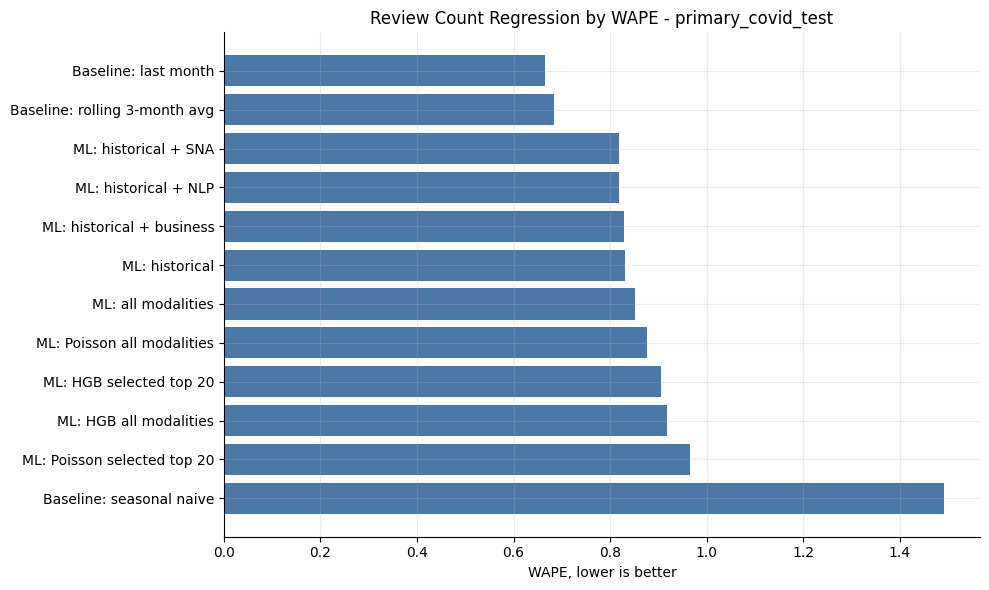

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_wape_comparison_primary_covid_test.png


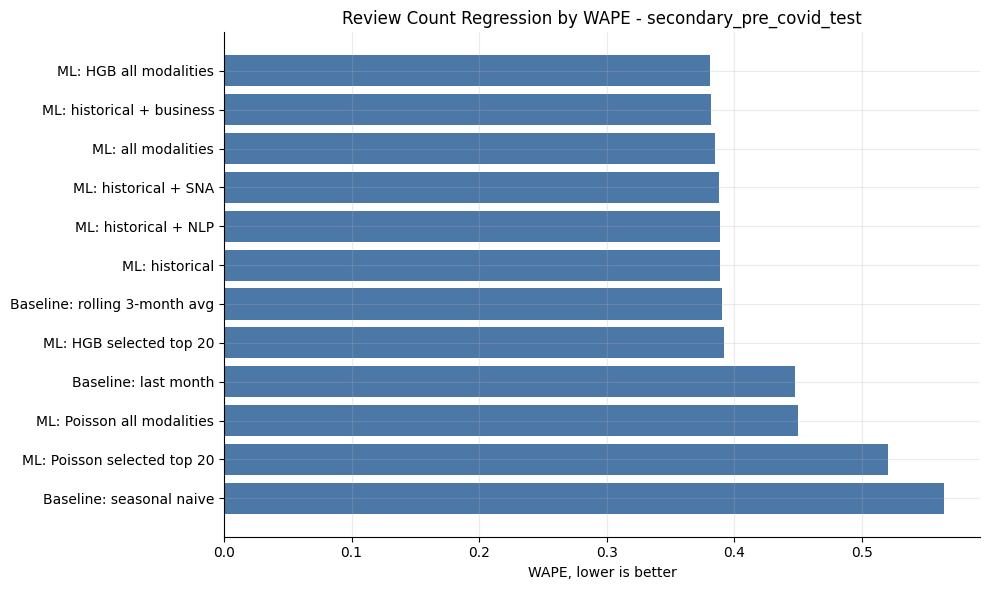

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_wape_comparison_secondary_pre_covid_test.png


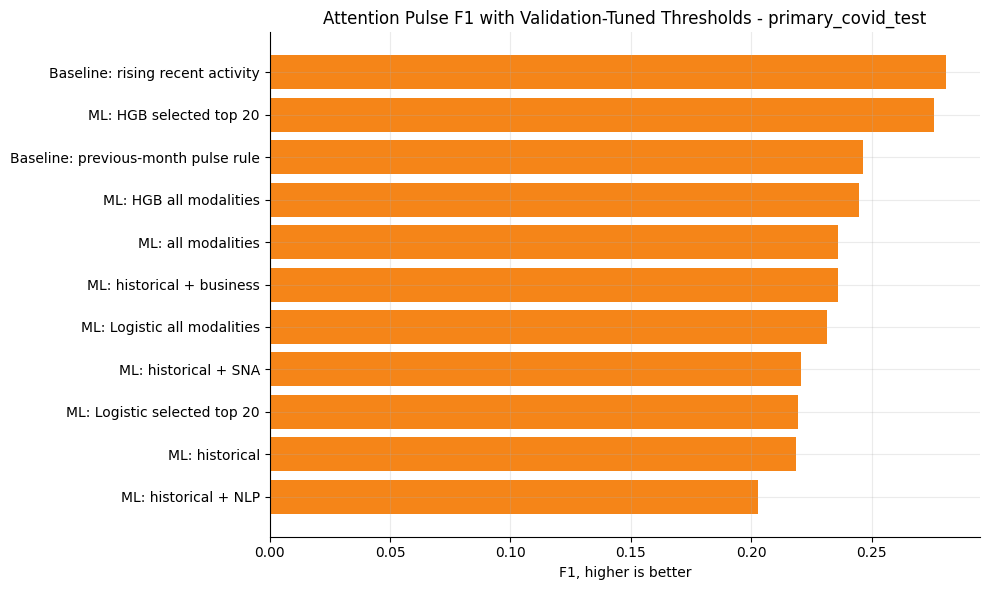

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_f1_comparison_primary_covid_test.png


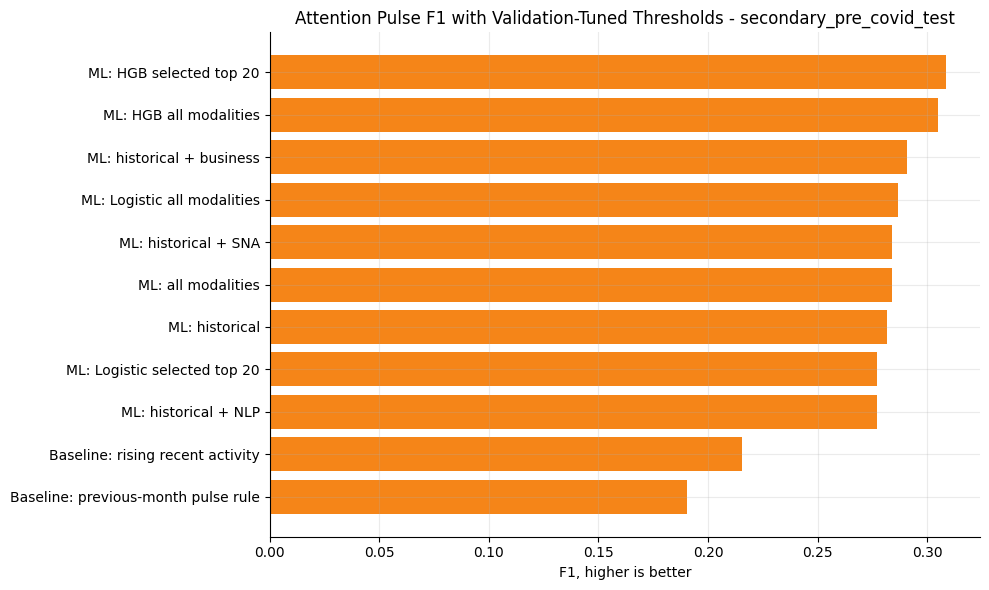

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_f1_comparison_secondary_pre_covid_test.png


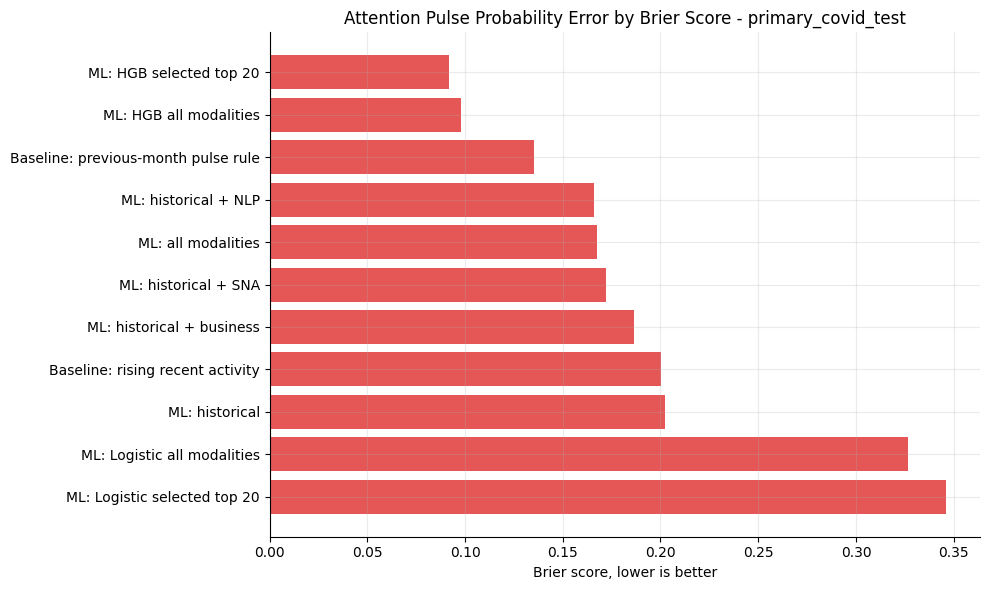

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_brier_comparison_primary_covid_test.png


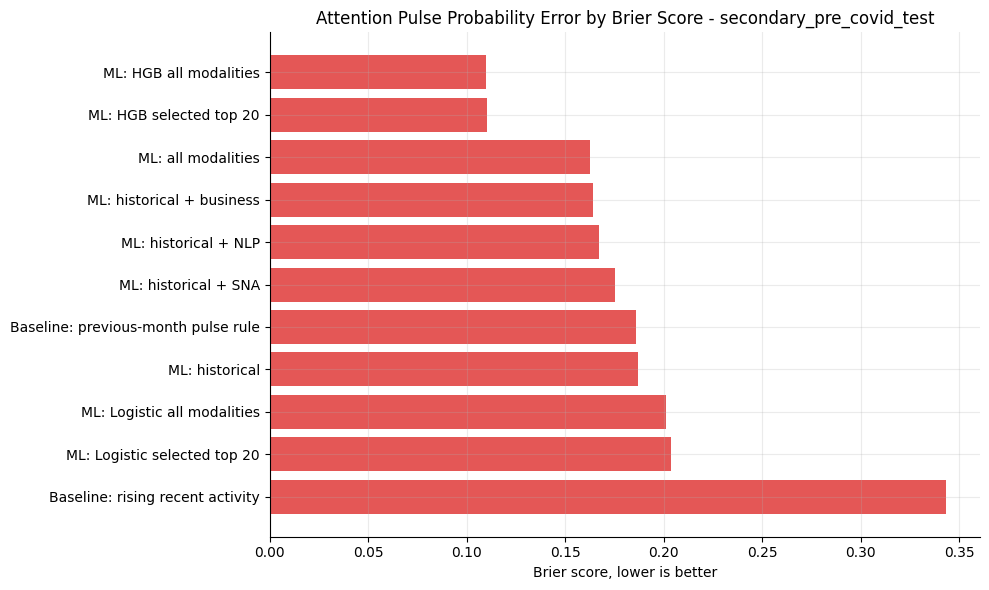

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_brier_comparison_secondary_pre_covid_test.png


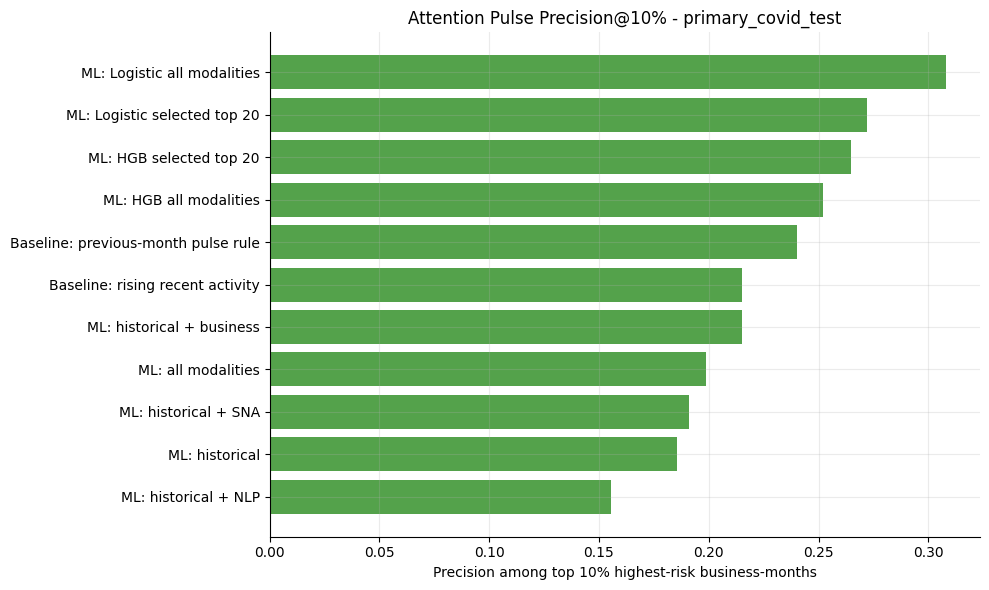

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_precision_at_10pct_primary_covid_test.png


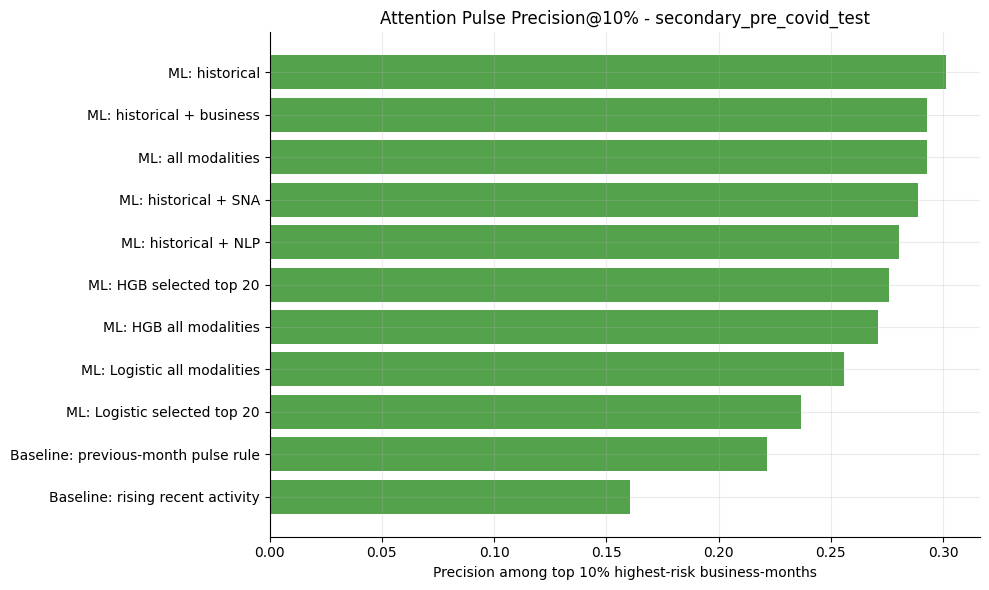

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_precision_at_10pct_secondary_pre_covid_test.png


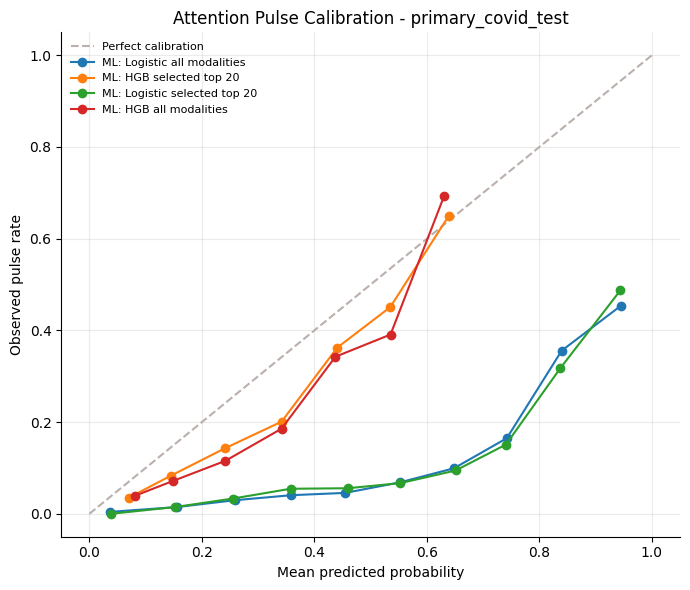

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_calibration_primary_covid_test.png


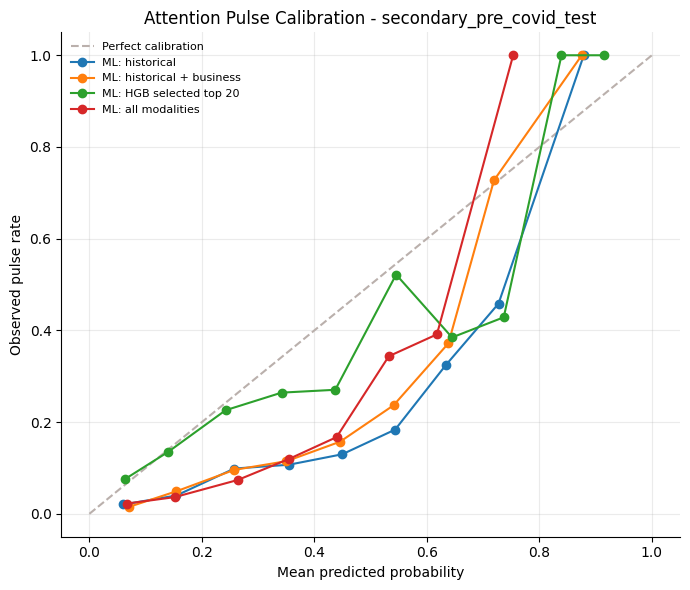

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_calibration_secondary_pre_covid_test.png


In [5]:
# Save comparison figures for regression, pulse F1, calibration, and top-k ranking.
for split_name in metrics_df["split"].unique():
    split_metrics = metrics_df[metrics_df["split"] == split_name].sort_values("WAPE")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_metrics["model"], split_metrics["WAPE"], color="#4C78A8")
    ax.invert_yaxis()
    ax.set_title(f"Review Count Regression by WAPE - {split_name}")
    ax.set_xlabel("WAPE, lower is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"review_count_wape_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_metrics_df["split"].unique():
    split_metrics = pulse_metrics_df[pulse_metrics_df["split"] == split_name].sort_values("F1", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_metrics["model"], split_metrics["F1"], color="#F58518")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse F1 with Validation-Tuned Thresholds - {split_name}")
    ax.set_xlabel("F1, higher is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_f1_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_metrics_df["split"].unique():
    split_metrics = pulse_metrics_df[pulse_metrics_df["split"] == split_name].sort_values("Brier")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_metrics["model"], split_metrics["Brier"], color="#E45756")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse Probability Error by Brier Score - {split_name}")
    ax.set_xlabel("Brier score, lower is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_brier_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_topk_metrics_df["split"].unique():
    split_topk = pulse_topk_metrics_df[
        (pulse_topk_metrics_df["split"] == split_name)
        & (pulse_topk_metrics_df["k_fraction"] == 0.10)
    ].sort_values("precision_at_k", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_topk["model"], split_topk["precision_at_k"], color="#54A24B")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse Precision@10% - {split_name}")
    ax.set_xlabel("Precision among top 10% highest-risk business-months")
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_precision_at_10pct_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_calibration_df["split"].unique():
    best_models = (
        pulse_metrics_df[pulse_metrics_df["split"] == split_name]
        .sort_values(["PR_AUC", "Brier"], ascending=[False, True])
        .head(4)["model"]
        .tolist()
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], color="#BAB0AC", linestyle="--", label="Perfect calibration")
    for model_name in best_models:
        line_df = pulse_calibration_df[(pulse_calibration_df["split"] == split_name) & (pulse_calibration_df["model"] == model_name)]
        ax.plot(line_df["mean_predicted_probability"], line_df["observed_pulse_rate"], marker="o", label=model_name)
    ax.set_title(f"Attention Pulse Calibration - {split_name}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed pulse rate")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_calibration_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

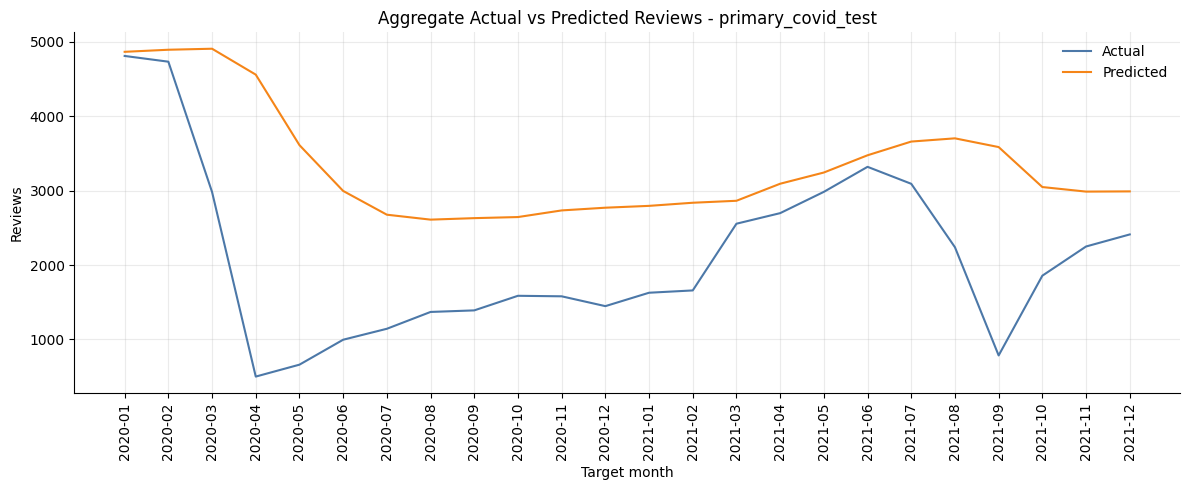

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_actual_vs_predicted_primary_covid_test.png


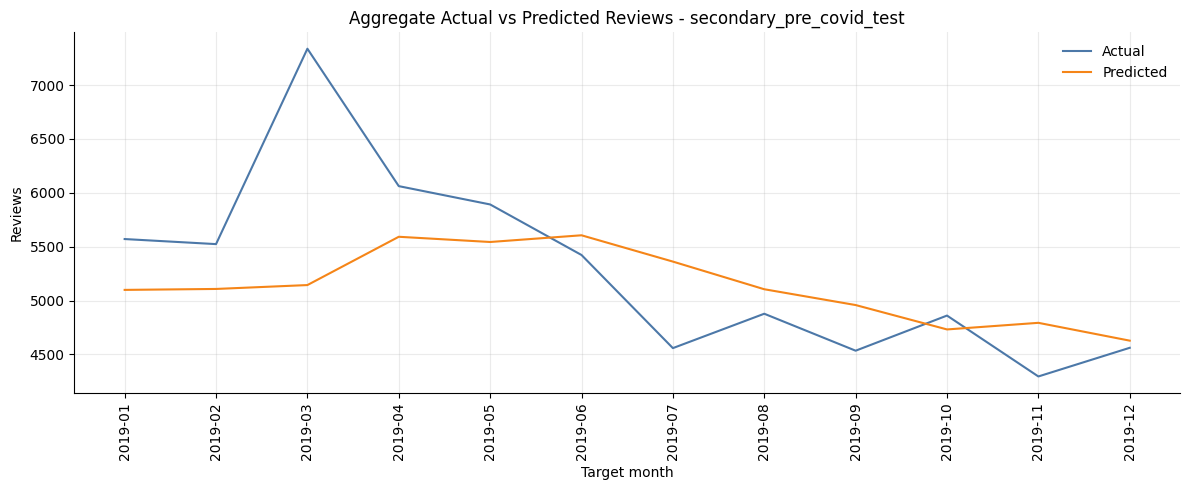

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_actual_vs_predicted_secondary_pre_covid_test.png


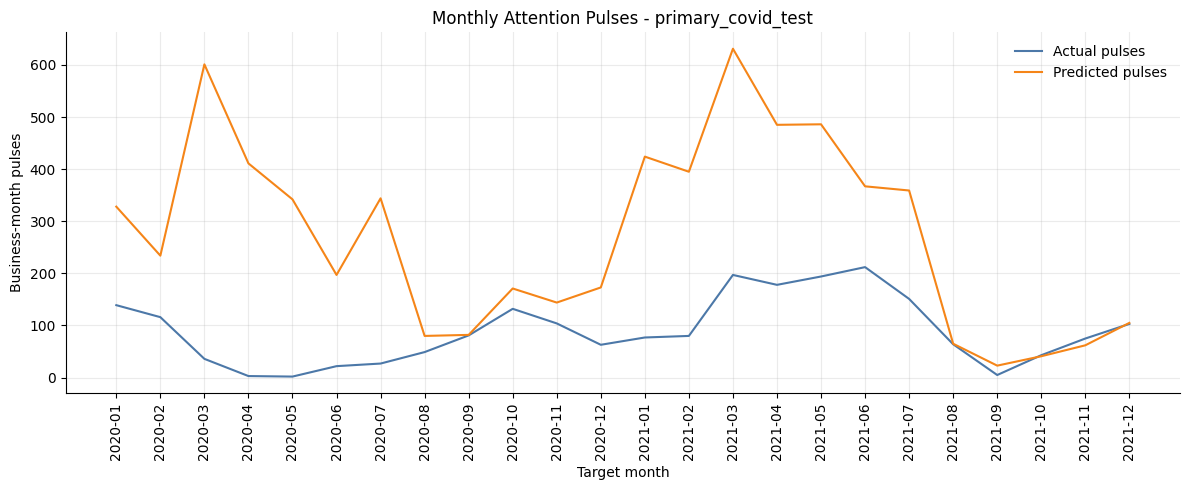

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_actual_vs_predicted_primary_covid_test.png


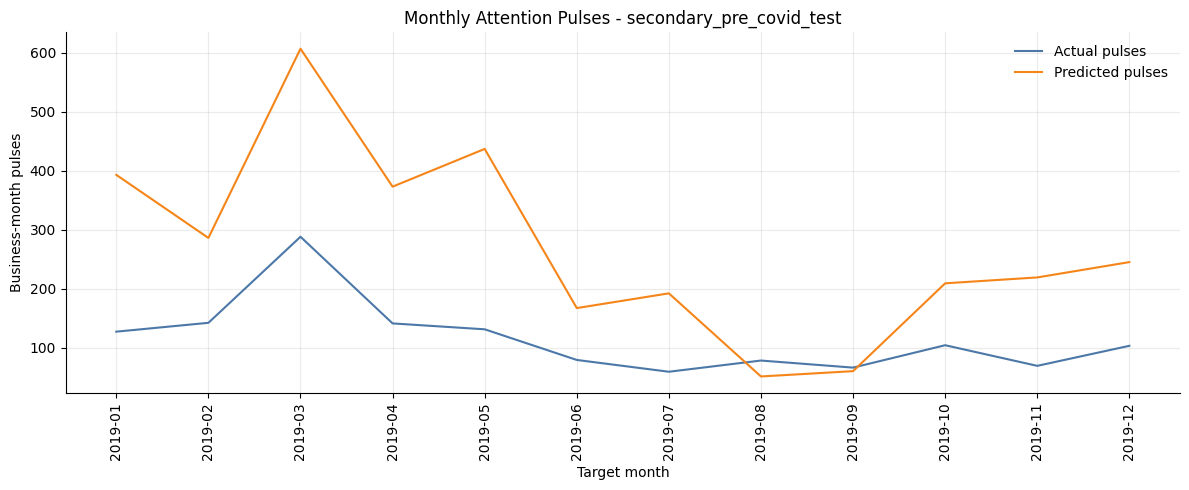

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_actual_vs_predicted_secondary_pre_covid_test.png


In [6]:
# Save aggregate actual-vs-predicted figures for the selected comparison model.
comparison_model = "ML: HGB selected top 20"
fallback_model = "ML: all modalities"
if comparison_model not in set(predictions_df["model"]):
    comparison_model = fallback_model

for split_name in predictions_df["split"].unique():
    plot_df = predictions_df[(predictions_df["split"] == split_name) & (predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual=("target_next_month_reviews", "sum"), predicted=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual"], label="Actual", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted"], label="Predicted", color="#F58518")
    ax.set_title(f"Aggregate Actual vs Predicted Reviews - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Reviews")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"review_count_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_predictions_df["split"].unique():
    plot_df = pulse_predictions_df[(pulse_predictions_df["split"] == split_name) & (pulse_predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual_pulses=("attention_pulse", "sum"), predicted_pulses=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual_pulses"], label="Actual pulses", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted_pulses"], label="Predicted pulses", color="#F58518")
    ax.set_title(f"Monthly Attention Pulses - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Business-month pulses")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

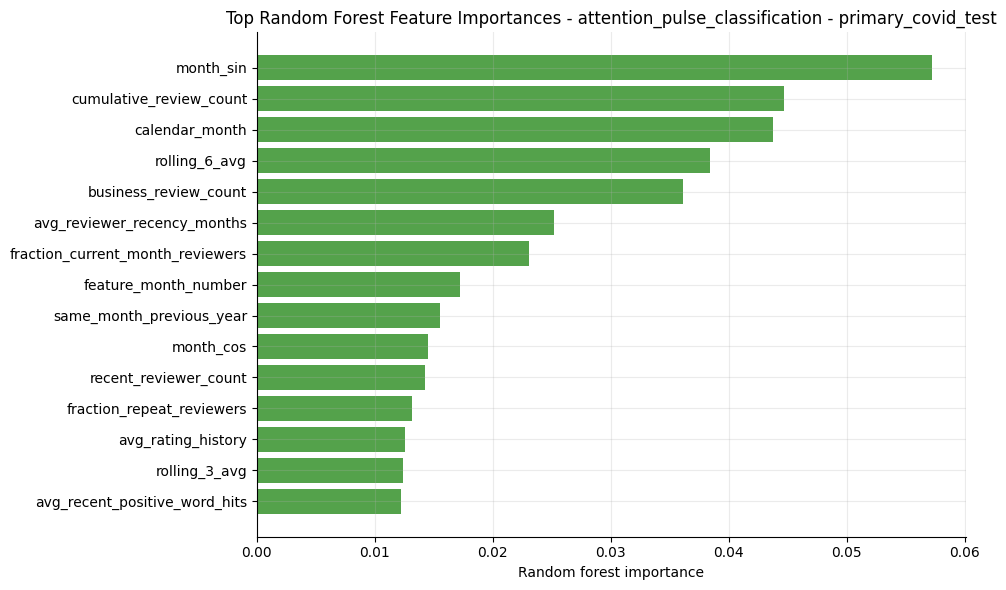

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_feature_importance_primary_covid_test.png


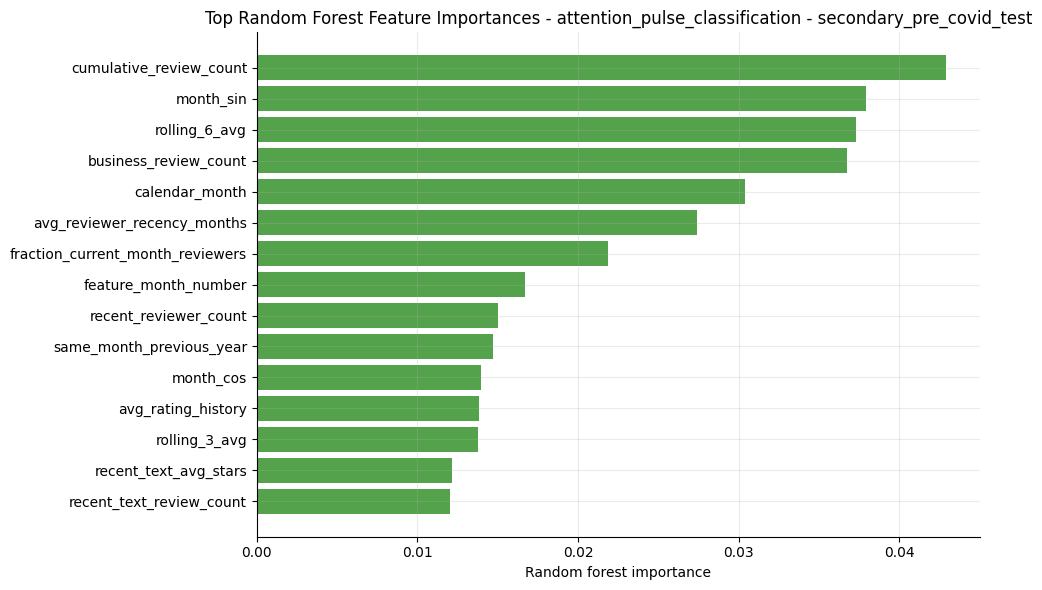

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_feature_importance_secondary_pre_covid_test.png


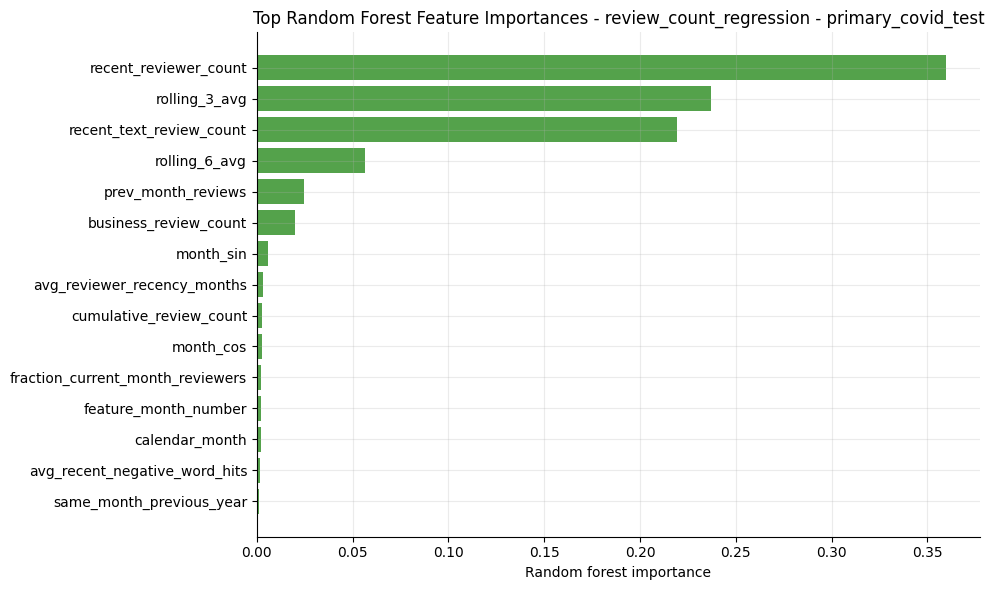

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_feature_importance_primary_covid_test.png


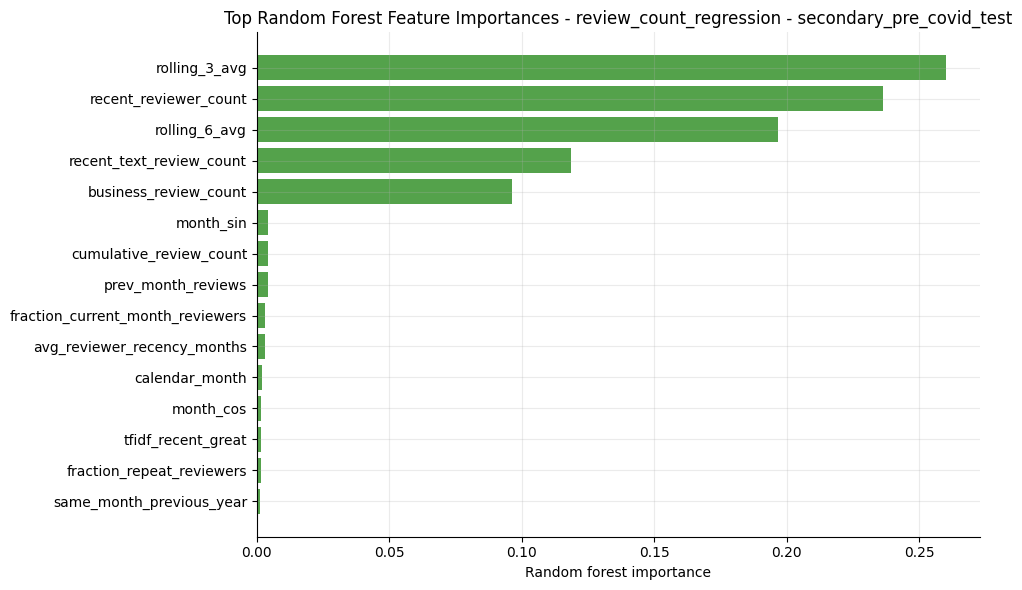

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_feature_importance_secondary_pre_covid_test.png


,task,split,feature,importance
207,attention_pulse_classification,primary_covid_test,month_sin,0.057243
204,attention_pulse_classification,primary_covid_test,cumulative_review_count,0.044647
206,attention_pulse_classification,primary_covid_test,calendar_month,0.043758
202,attention_pulse_classification,primary_covid_test,rolling_6_avg,0.038416
211,attention_pulse_classification,primary_covid_test,business_review_count,0.036128
237,attention_pulse_classification,primary_covid_test,avg_reviewer_recency_months,0.025148
238,attention_pulse_classification,primary_covid_test,fraction_current_month_reviewers,0.023041
209,attention_pulse_classification,primary_covid_test,feature_month_number,0.017195
203,attention_pulse_classification,primary_covid_test,same_month_previous_year,0.015562
208,attention_pulse_classification,primary_covid_test,month_cos,0.014495


In [7]:
# Extract and plot Random Forest feature importances where available.
importance_rows = []
for (split_name, model_name), (model, features, family) in regression_models.items():
    if model_name != "ML: all modalities" or not hasattr(model, "feature_importances_"):
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"task": "review_count_regression", "split": split_name, "feature": feature, "importance": importance})
for (split_name, model_name), (model, features, family, decision_threshold) in pulse_models.items():
    if model_name != "ML: all modalities" or not hasattr(model, "feature_importances_"):
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"task": "attention_pulse_classification", "split": split_name, "feature": feature, "importance": importance})

importance_df = pd.DataFrame(importance_rows).sort_values(["task", "split", "importance"], ascending=[True, True, False])

for (task, split_name), group in importance_df.groupby(["task", "split"]):
    top_importance = group.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_importance["feature"], top_importance["importance"], color="#54A24B")
    ax.set_title(f"Top Random Forest Feature Importances - {task} - {split_name}")
    ax.set_xlabel("Random forest importance")
    fig.tight_layout()
    safe_task = task.replace("_classification", "").replace("_regression", "")
    path = FIGURES_DIR / f"{safe_task}_feature_importance_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

importance_df.head(20)

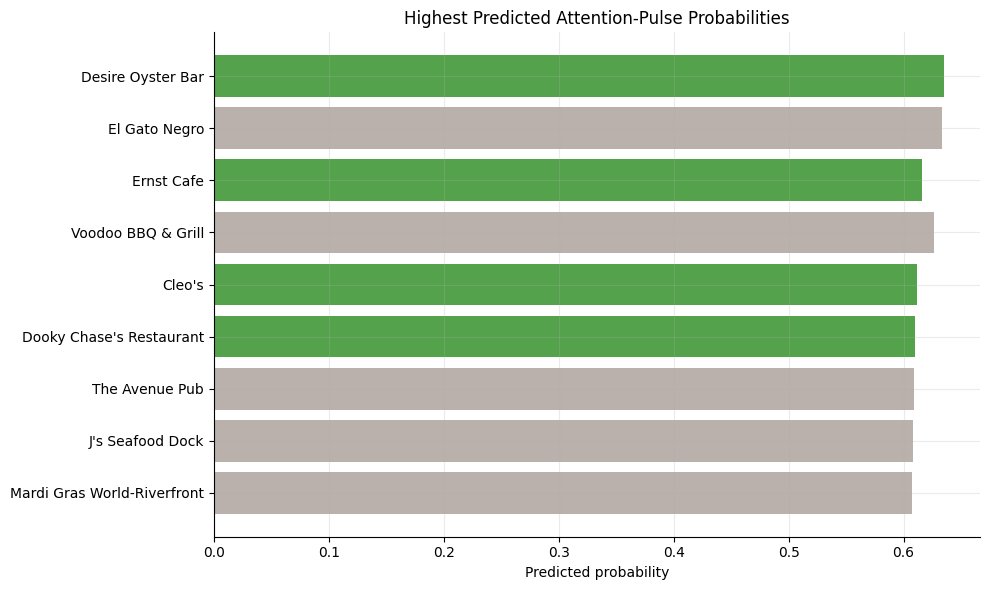

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_top_predicted_examples.png


,business_id,name,target_month_str,attention_pulse,target_next_month_reviews,pulse_baseline_reviews,pulse_relative_lift,probability
0,JvawJ9bSr22xn4R9oLvl_w,Desire Oyster Bar,2021-03,1,5.0,1.833333,2.727273,0.634718
1,SA10MB4CEw0YikMuhOxyYw,El Gato Negro,2020-03,0,2.0,3.666667,0.545455,0.633344
2,UKpPU6X97oPd-dkCK8cheQ,Voodoo BBQ & Grill,2020-03,0,4.0,2.666667,1.500000,0.626579
3,lK-YaoQ670dGJrmaqyJTBA,Ernst Cafe,2021-03,1,5.0,1.500000,3.333333,0.615855
4,UKpPU6X97oPd-dkCK8cheQ,Voodoo BBQ & Grill,2020-04,0,0.0,2.500000,0.000000,0.614147
5,WNhcS2zi4zAqA2TbduVINQ,Cleo's,2020-03,1,10.0,2.666667,3.750000,0.611464
6,R9TBf8VqGQ83kvdIxkC9RQ,Dooky Chase's Restaurant,2021-03,1,7.0,2.666667,2.625000,0.610149
7,JhpRI9m71ybWHkAqRdL0Tg,The Avenue Pub,2020-04,0,0.0,1.500000,0.000000,0.608778
8,fsFZQ2ZbTutgUlnWPhTU6A,J's Seafood Dock,2020-04,0,0.0,3.666667,0.000000,0.607839
9,BVOjxoXijWPfINv1eUGDKw,Mardi Gras World-Riverfront,2021-03,0,2.0,1.500000,1.333333,0.607365


In [8]:
# Save high-probability attention-pulse examples for qualitative review.
example_split = "primary_covid_test"
example_model = "ML: all modalities"
examples = (
    pulse_predictions_df[(pulse_predictions_df["split"] == example_split) & (pulse_predictions_df["model"] == example_model)]
    .sort_values("probability", ascending=False)
    .head(10)
    .merge(business_lookup, on="business_id", how="left")
)

fig, ax = plt.subplots(figsize=(10, 6))
labels = examples["name"].fillna(examples["business_id"]).str.slice(0, 35)
colors = np.where(examples["attention_pulse"].eq(1), "#54A24B", "#BAB0AC")
ax.barh(labels[::-1], examples["probability"].values[::-1], color=colors[::-1])
ax.set_title("Highest Predicted Attention-Pulse Probabilities")
ax.set_xlabel("Predicted probability")
fig.tight_layout()
path = FIGURES_DIR / "attention_pulse_top_predicted_examples.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

examples[["business_id", "name", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift", "probability"]]

## Modeling Limitations

- Stronger model families do not guarantee better community insight; simple baselines remain essential reference points.
- COVID-era evaluation is intentionally difficult because the test period contains structural disruption rather than ordinary seasonality.
- Pulse classification is a rare-event problem, so accuracy is less informative than F1, PR-AUC, calibration, and top-k retrieval metrics.
- TF-IDF features are deliberately capped and exploratory; they should be interpreted as recent language/topic indicators, not full NLP understanding.

## Modeling Takeaways

- The corrected evaluation uses train, validation, and test periods for each chronological split.
- Review-count regression now compares temporal baselines, Random Forest ablations, HistGradientBoosting, Poisson count models, and selected-feature variants.
- Attention-pulse classifiers use validation-tuned decision thresholds instead of the default `0.5` cutoff.
- Logistic regression is included as an interpretable classification baseline, while HistGradientBoosting tests whether a stronger nonlinear learner improves pulse risk ranking.
- Selected-feature models test whether a smaller all-modality subset is more stable than the full all-modality feature set.
- NLP model groups now include VADER monthly sentiment features alongside text-length, lexicon, and capped TF-IDF signals.
- Probability diagnostics are reported with Brier score and calibration curves because pulse probabilities are only useful if they behave like meaningful risk estimates.
- Top-k metrics add a retrieval view of the problem: can the model surface the most likely future attention pulses for analyst review?